# Computer Vision (CSE 6367) project for icon captioning

###Sabrina Haque
###1001843912

In [28]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Mon May  8 01:02:03 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 525.85.12    Driver Version: 525.85.12    CUDA Version: 12.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   75C    P0    29W /  70W |   1819MiB / 15360MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [18]:
!pip install transformers

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 85.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 107.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 29.1 MB/s eta 0:00:00


In [ ]:
import copy 
from typing import TYPE_CHECKING, Any, Mapping, Optional, OrderedDict

from packaging import version
from transformers import PretrainedConfig
from transformers.utils import logging
from transformers import AutoConfig
if TYPE_CHECKING:
    from transformers import PreTrainedTokenizerBase, TensorType

logger = logging.get_logger(__name__)

In [ ]:
import gc
import os
import tempfile
from typing import Optional, Tuple, Union

import torch
from torch import nn
from torch.nn import CrossEntropyLoss

from transformers import PretrainedConfig
from transformers.modeling_outputs  import BaseModelOutput, Seq2SeqLMOutput
from transformers import PreTrainedModel
from transformers.utils import logging
#from ...utils import add_start_docstrings, add_start_docstrings_to_model_forward, logging, replace_return_docstrings
from transformers  import AutoConfig
from transformers import AutoModel, AutoModelForCausalLM
from transformers.file_utils import ModelOutput
logger = logging.get_logger(__name__)

## Configuration for Custom Encoder Decoder

In [ ]:
class CustomVisionEncoderDecoderConfig(PretrainedConfig):
    model_type = "custom_vision_encoder_decoder"
    is_composition = True

    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        if "encoder" not in kwargs or "decoder" not in kwargs:
            raise ValueError(
                f"A configuraton of type {self.model_type} cannot be instantiated because "
                f"not both `encoder` and `decoder` sub-configurations are passed, but only {kwargs}"
            )

        encoder_config = kwargs.pop("encoder")
        encoder_model_type = encoder_config.pop("model_type")
        decoder_config = kwargs.pop("decoder")
        decoder_model_type = decoder_config.pop("model_type")

        self.encoder = AutoConfig.for_model(encoder_model_type, **encoder_config)
        self.decoder = AutoConfig.for_model(decoder_model_type, **decoder_config)
        self.is_encoder_decoder = True

    @classmethod
    def from_encoder_decoder_configs(
        cls, encoder_config: PretrainedConfig, decoder_config: PretrainedConfig, **kwargs
    ) -> PretrainedConfig:
        logger.info("Setting `config.is_decoder=True` and `config.add_cross_attention=True` for decoder_config")
        decoder_config.is_decoder = True
        decoder_config.add_cross_attention = True

        return cls(encoder=encoder_config.to_dict(), decoder=decoder_config.to_dict(), **kwargs)

    def to_dict(self):
        """
        Serializes this instance to a Python dictionary. Override the default *to_dict()* from *PretrainedConfig*.
        Returns:
            `Dict[str, any]`: Dictionary of all the attributes that make up this configuration instance,
        """
        output = copy.deepcopy(self.__dict__)
        output["encoder"] = self.encoder.to_dict()
        output["decoder"] = self.decoder.to_dict()
        output["model_type"] = self.__class__.model_type
        return output


In [ ]:
def shift_tokens_right(input_ids: torch.Tensor, pad_token_id: int, decoder_start_token_id: int):
    """
    Shift input ids one token to the right.
    """
    shifted_input_ids = input_ids.new_zeros(input_ids.shape)
    shifted_input_ids[:, 1:] = input_ids[:, :-1].clone()
    if decoder_start_token_id is None:
        raise ValueError("Make sure to set the decoder_start_token_id attribute of the model's configuration.")
    shifted_input_ids[:, 0] = decoder_start_token_id

    if pad_token_id is None:
        raise ValueError("Make sure to set the pad_token_id attribute of the model's configuration.")
    # replace possible -100 values in labels by `pad_token_id`
    shifted_input_ids.masked_fill_(shifted_input_ids == -100, pad_token_id)

    return shifted_input_ids

## Custom encoder module

In [ ]:
import torch.nn as nn

class CustomEncoders(ModelOutput):
    attentions: Optional[bool] = None,
    hidden_states: Optional[Tuple[Tuple[torch.FloatTensor]]] = None,
    last_hidden_state: Optional[Tuple[Tuple[torch.FloatTensor]]] = None,
    pooler_output: Optional[Tuple[Tuple[torch.FloatTensor]]] = None,
    hidden_states_mask: Optional[Tuple[Tuple[torch.FloatTensor]]] = None
    
    


class Custom_encoders(torch.nn.Module):

    def combine_pixel_values(self,Sizes, FeatureExtractor, XFullImage, XCrop):
        #WordSize == featurextractor.size
        Images_p = torch.zeros((len(Sizes), max(Sizes) * 3, FeatureExtractor.size, FeatureExtractor.size), dtype=torch.float32)
        for i in range(len(Sizes)):
            Images = FeatureExtractor(images=[XFullImage[i], *XCrop[i][0:Sizes[i] - 1].tolist()], return_tensors="pt")
            Images_p[i][0:3 * Sizes[i]][:][:] = Images["pixel_values"].reshape(1, 3 * Sizes[i],  FeatureExtractor.size, FeatureExtractor.size)
        return Images_p
    #raise NotImplementedError("Check the logic implemented in the RunTrain.py.\n Start encoding the images and them vertically stacking the colour channels the model requires atleast 6 colour channels for its dual encoders (1 image per encoder)\n The first 3 Colour channels (a image) are used on a encoder, while the rest n multiple of 3 (multiple images) will be encoded by the second encoder \n The input Should be {Batch, max number of channels (when necessary padding with 0 for the next dimentions), FeatureExtration.encTokens.size , FeatureExtration.encTokens.size} ")

    def split_pixel_values(self, pixel_values, batch_lengths=None):
        #print(f"original : {pixel_values.shape}")
        if(len(pixel_values.shape)>4):
          #print("true")
          pixel_values=pixel_values.squeeze()

        if(len(pixel_values.shape)<4):
          #print("true")
          pixel_values=pixel_values.unsqueeze()
        return_value = dict()
        #print(f"original : {pixel_values.shape}")

        return_value['Full_Image'], return_value['Crop'] = torch.split(pixel_values, 3, dim=1)
    
        return  return_value

    def __init__(self, model_args=None, config=None, name_or_path=None, kwargs_encoder=None):
        super().__init__()
        if config is None and (model_args is not None and name_or_path is not None):
            self.encoder = AutoModel.from_pretrained(name_or_path, *model_args,
                                                           **kwargs_encoder)
            #self.encoder_label = AutoModel.from_pretrained(name_or_path, *model_args,**kwargs_encoder)
            self.update_config(self.encoder.config)
            self.config_class = self.encoder.config_class
            self.base_model_prefix = self.encoder.base_model_prefix
            self.main_input_name = self.encoder.main_input_name
            self.supports_gradient_checkpointing = self.encoder.supports_gradient_checkpointing
        elif config is not None and (model_args is None and name_or_path is None):
            self.config = config
            self.encoder = AutoModel.from_config(config)
            #self.encoder_label = AutoModel.from_config(config)
            self.config_class = self.encoder.config_class
            self.base_model_prefix = self.encoder.base_model_prefix
            self.main_input_name = self.encoder.main_input_name
            self.supports_gradient_checkpointing = self.encoder.supports_gradient_checkpointing
        else:
            raise ValueError("Not enough parameters for a encoder configuration")

    def update_config(self, config):
        self.config = config
        self.encoder.config = config
        

    def get_input_embeddings(self):
        return self.encoder.get_input_embeddings()

    def get_output_embeddings(self):
        return None

    def reshape_Tensor(self, input_value):
        sizes = []
        for i in range(len(input_value)):
            sizes.append(input_value[i].shape[0])
        output_value = []
        for i in range(len(input_value)):
            mid_value = []
            for j in range(input_value[i].shape[0]):
                mid_value.append(input_value[i][j])
            for j in range(max(sizes) - input_value[i].shape[0]):
                mid_value.append(torch.zeros(input_value[i][0].shape, dtype=input_value[i].dtype, device=input_value[i].device))
            output_value.append(torch.cat(mid_value, dim=0).unsqueeze(0))
        return torch.cat(output_value, dim=0)

    def forward(self, pixel_values, output_attentions, output_hidden_states, return_dict, **kwargs_encoder):
        

        if pixel_values is None:
            raise ValueError("You have to specify pixel_values for both encoders")
        try:
            pixel_values = self.split_pixel_values(pixel_values)
        except:
            print(pixel_values.shape)
            raise ValueError("Use encoder.combine_pixel_values to combine both image feature extration for this model")

        if pixel_values['Full_Image'] is None or pixel_values['Crop'] is None:
            raise ValueError("You have to specify pixel_values for both encoders")

        if pixel_values['Full_Image'].shape[0] != len(pixel_values['Crop']):
            raise ValueError("There was a problem with the split_pixel_values there must be the same full images as crop arrays")

        fc_layer1=nn.Linear(768,256)
        fc_layer1.to(device)
        fc_layer2=nn.Linear(768,512)
        fc_layer2.to(device)
        # print(pixel_values['Full_Image'].shape)
        # print(pixel_values['Crop'].shape)
        encoder_outputs_1 = self.encoder(
                pixel_values['Full_Image'],
                output_attentions=output_attentions,
                output_hidden_states=output_hidden_states,
                return_dict=return_dict,
                **kwargs_encoder,
            )
        
        hidden_state_image=fc_layer1(encoder_outputs_1[0])
        pooler_output_image=fc_layer1(encoder_outputs_1.pooler_output)
        last_hidden_state_image=fc_layer1(encoder_outputs_1.last_hidden_state)

        encoder_outputs_2 = self.encoder(
                pixel_values['Crop'],
                output_attentions=output_attentions,
                output_hidden_states=output_hidden_states,
                return_dict=return_dict,
                **kwargs_encoder,
            )
        hidden_state_crop=fc_layer2(encoder_outputs_2[0])
        pooler_output_crop=fc_layer2(encoder_outputs_2.pooler_output)
        last_hidden_state_crop=fc_layer2(encoder_outputs_2.last_hidden_state)
        multi_encoder_pooler=[]
       
        multi_encoder_pooler.append(torch.cat((encoder_outputs_1.pooler_output, encoder_outputs_2.pooler_output), dim=0))

        encoder_hidden_states=torch.cat((hidden_state_crop,hidden_state_image),dim=-1)
        encoder_pooler_output=torch.cat((pooler_output_crop,pooler_output_image),dim=-1)
        last_hidden_state=torch.cat((last_hidden_state_crop,last_hidden_state_image),dim=-1)


        # encoder_hidden_states = torch.cat([encoder_outputs_1[0],encoder_outputs_2[0]],dim=-1)
        # encoder_hidden_states = fc_layer(encoder_hidden_states)

        # encoder_pooler_output =torch.cat([encoder_outputs_1.pooler_output,encoder_outputs_2.pooler_output],dim=-1)
        # encoder_pooler_output =fc_layer(encoder_pooler_output)

        # last_hidden_state=torch.cat([encoder_outputs_1.last_hidden_state,encoder_outputs_2.last_hidden_state],dim=-1)
   
        
        # last_hidden_state=fc_layer(last_hidden_state)
        
        encoder_attentions=encoder_outputs_1.attentions



        
        
        

        


        # if len(batch_lengths) > 1:
        #     last_hidden_state_mask = torch.zeros(encoder_last_hidden_state.shape[:2], dtype=torch.int16, device=encoder_last_hidden_state.device)
        #     for i in range(last_hidden_state_mask.shape[0]):
        #         last_hidden_state_mask[i][:int(batch_lengths[i] * encoder_outputs_image[0].shape[1])] = torch.ones(int(batch_lengths[i] * encoder_outputs_image[0].shape[1]), dtype=torch.int16, device=encoder_last_hidden_state.device)
        # else:
        last_hidden_state_mask = None

        return CustomEncoders(attentions=encoder_attentions,
                            hidden_states=encoder_hidden_states,
                            last_hidden_state=last_hidden_state,
                            pooler_output=encoder_pooler_output,
                            last_hidden_state_mask=last_hidden_state_mask
                            )

## Custom decoder module

In [ ]:
class CustomDecoders(ModelOutput):
    logits_name: torch.FloatTensor = None
    logits_location: torch.FloatTensor = None
    logits_date: torch.FloatTensor = None
    past_key_values_name: Optional[Tuple[Tuple[torch.FloatTensor]]] = None
    past_key_values_location: Optional[Tuple[Tuple[torch.FloatTensor]]] = None
    past_key_values_date: Optional[Tuple[Tuple[torch.FloatTensor]]] = None
    hidden_states_name: Optional[Tuple[torch.FloatTensor]] = None
    hidden_states_location: Optional[Tuple[torch.FloatTensor]] = None
    hidden_states_date: Optional[Tuple[torch.FloatTensor]] = None
    attentions_name: Optional[Tuple[torch.FloatTensor]] = None
    attentions_location: Optional[Tuple[torch.FloatTensor]] = None
    attentions_date: Optional[Tuple[torch.FloatTensor]] = None
    
    output: Optional[Tuple[torch.FloatTensor]] = None
    


class Custom_decoders(torch.nn.Module):

    def combine_labels(self,Tokenizer ,YName, YLocation, YDate):
        return Tokenizer([*YName, *YLocation, *YDate], padding=True, truncation=True, max_length=512, return_tensors="pt")

    def __init__(self, config=None, name_or_path=None, kwargs_decoder=None):
        super().__init__()
        if config is None and name_or_path is not None:
            self.decoder = AutoModelForCausalLM.from_pretrained(name_or_path, **kwargs_decoder)
           
            self.update_config(self.decoder.config)
        elif config is not None and name_or_path is None:
            self.config = config
            self.decoder = AutoModelForCausalLM.from_config(config)
            
        else:
            raise ValueError("Not enough  raise parameters for a decoder configuration")


    def _reorder_cache(self, past, beam_idx):
        return self.decoder_name._reorder_cache(past, beam_idx), self.decoder_location._reorder_cache(past, beam_idx), self.decoder_date._reorder_cache(past, beam_idx)

    def get_output_embeddings(self):
        return self.decoder_name.get_output_embeddings()

    def set_output_embeddings(self, new_embeddings):
        return self.decoder_name.set_output_embeddings(new_embeddings), self.decoder_location.set_output_embeddings(
            new_embeddings), self.decoder_date.set_output_embeddings(new_embeddings)

    def update_config(self, config):
        self.config = config
        self.decoder.config = config
       

    # def split_decoder_input_withoutmask(self, InputVal):
    #     if InputVal.shape[0] % 3 != 0 and InputVal.shape[0] < 3:
    #         raise ValueError("The depth of the attention_mask must be the same as the input_ids and both depth must be  multiple of 3 to match: Name..., Locality..., Date...")
    #     batch = int(InputVal.shape[0] / 3)
    #     OutputVal = dict()
    #     OutputVal['Name'] = InputVal[0 * batch:1 * batch]
    #     OutputVal['Location'] = InputVal[1 * batch:2 * batch]
    #     OutputVal['Date'] = InputVal[2 * batch:3 * batch]
    #     return OutputVal

    # def split_decoder_input_withmask(self, in_input_ids, in_attention_mask):
    #     if in_input_ids.shape[0] % 3 != 0 and in_attention_mask.shape[0] % 3 != 0 and in_input_ids.shape[0] != in_attention_mask.shape[0]:
    #         raise ValueError("The depth of the attention_mask must be the same as the input_ids and both depth must be multiple of 3 to match: Name..., Locality..., Date...")
    #     batch = int(in_input_ids.shape[0] / 3)
    #     if batch >= 2:
    #         input_ids = self.split_decoder_input_withoutmask(in_input_ids)
    #         attention_mask = self.split_decoder_input_withoutmask(in_attention_mask)
    #     else:
    #         input_ids = dict()
    #         attention_mask = dict()
    #         sizes = []
    #         for i in range(in_attention_mask.shape[0]):
    #             sizes.append(int(sum(in_attention_mask[i])))
    #         input_ids['Name'] = in_input_ids[0][:sizes[0]]
    #         input_ids['Name'] = torch.unsqueeze(input_ids['Name'], 0)
    #         input_ids['Location'] = in_input_ids[1][:sizes[1]]
    #         input_ids['Location'] = torch.unsqueeze(input_ids['Location'], 0)
    #         input_ids['Date'] = in_input_ids[2][:sizes[2]]
    #         input_ids['Date'] = torch.unsqueeze(input_ids['Date'], 0)
    #         attention_mask['Name'] = in_attention_mask[0][:sizes[0]]
    #         attention_mask['Name'] = torch.unsqueeze(attention_mask['Name'], 0)
    #         attention_mask['Location'] = in_attention_mask[1][:sizes[1]]
    #         attention_mask['Location'] = torch.unsqueeze(attention_mask['Location'], 0)
    #         attention_mask['Date'] = in_attention_mask[2][:sizes[2]]
    #         attention_mask['Date'] = torch.unsqueeze(attention_mask['Date'], 0)
    #     return input_ids, attention_mask

    def forward(self, input_ids, attention_mask, encoder_hidden_states, encoder_attention_mask, inputs_embeds, output_attentions, output_hidden_states, use_cache, past_key_values, return_dict, **kwargs_decoder):

        # input_ids, attention_mask = self.split_decoder_input_withmask(input_ids, attention_mask)

        # if inputs_embeds is None:
        #     inputs_embeds = dict()
        #     inputs_embeds['Name'] = None
        #     inputs_embeds['Location'] = None
        #     inputs_embeds['Date'] = None
        # else:
        #     inputs_embeds = self.split_decoder_input_withoutmask(inputs_embeds)

        decoder_outputs = self.decoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            encoder_hidden_states=encoder_hidden_states,
            encoder_attention_mask=encoder_attention_mask,
            inputs_embeds=inputs_embeds,
            output_attentions=output_attentions,
            output_hidden_states=output_hidden_states,
            use_cache=use_cache,
            past_key_values=past_key_values,
            return_dict=return_dict,
            **kwargs_decoder,
        )


        return CustomDecoders(
            logits=decoder_outputs.logits,
          
            past_key_values=decoder_outputs.past_key_values,
            
            hidden_states=decoder_outputs.hidden_states,
        
            attentions=decoder_outputs.attentions,
         
            cross_attentions=decoder_outputs.cross_attentions,
         
            output=decoder_outputs[0]
            
        )


## CustomVisionEncoderDecoderModel

In [ ]:
class CustomSeq2SeqLMOutput(ModelOutput):
  
    loss: Optional[torch.FloatTensor] = None
    encoder_outputs: Optional[CustomEncoders] = None
    decoder_outputs: Optional[CustomDecoders] = None


class CustomVisionEncoderDecoderModel(PreTrainedModel):
    r"""
    [`VisionEncoderDecoderModel`] is a generic model class that will be instantiated as a transformer architecture with
    one of the base vision model classes of the library as encoder and another one as decoder when created with the
    :meth*~transformers.AutoModel.from_pretrained* class method for the encoder and
    :meth*~transformers.AutoModelForCausalLM.from_pretrained* class method for the decoder.
    """
    config_class = CustomVisionEncoderDecoderConfig
    base_model_prefix = "custom_vision_encoder_decoder"
    main_input_name = "pixel_values"
    supports_gradient_checkpointing = True
    training = bool

    def __init__(
        self,
        config: Optional[PretrainedConfig] = None,
        encoder: Optional[PreTrainedModel] = None,
        decoder: Optional[PreTrainedModel] = None,
        training: Optional[bool] = None
    ):
        if training is None:
            print("setting up training to True")
            training = True

        if config is None and (encoder is None or decoder is None):
            raise ValueError("Either a configuration or an encoder and a decoder has to be provided.")
        if config is None:
            config = CustomVisionEncoderDecoderConfig.from_encoder_decoder_configs(encoder.config, decoder.config)            
        else:
            if not isinstance(config, self.config_class):
                raise ValueError(f"Config: {config} has to be of type {self.config_class}")

        if config.decoder.cross_attention_hidden_size is not None:
            if config.decoder.cross_attention_hidden_size != config.encoder.hidden_size:
                raise ValueError(
                    "If `cross_attention_hidden_size` is specified in the decoder's configuration, it has to be equal"
                    f" to the encoder's `hidden_size`. Got {config.decoder.cross_attention_hidden_size} for"
                    f" `config.decoder.cross_attention_hidden_size` and {config.encoder.hidden_size} for"
                    " `config.encoder.hidden_size`."
                )

        # initialize with config
        # make sure input & output embeddings is not tied
        config.tie_word_embeddings = False
        super().__init__(config)

        if encoder is None:
            encoder = Custom_encoders(config=config.encoder)
            #encoder = AutoModel.from_config(config.encoder)
            print("encoder initialized")

        if decoder is None:
            
            decoder = AutoModelForCausalLM.from_config(config.decoder)
            #decoder = AutoModelForCausalLM.from_config(config.decoder)

        self.encoder = encoder
        self.decoder = decoder
        #print(encoder)
        if self.encoder.config.to_dict() != self.config.encoder.to_dict():
            logger.warning(
                f"Config of the encoder: {self.encoder.__class__} is overwritten by shared encoder config:"
                f" {self.config.encoder}"
            )
        if self.decoder.config.to_dict() != self.config.decoder.to_dict():
            logger.warning(
                f"Config of the decoder: {self.decoder.__class__} is overwritten by shared decoder config:"
                f" {self.config.decoder}"
            )

        # make sure that the individual model's config refers to the shared config
        # so that the updates to the config will be synced
        self.encoder.update_config(self.config.encoder)

        # if training:
        #     self.decoder.update_config(self.config.decoder)
        # else:
        self.decoder.config = self.config.decoder

        # encoder outputs might need to be projected to different dimension for decoder
        if (
            self.encoder.config.hidden_size != self.decoder.config.hidden_size
            and self.decoder.config.cross_attention_hidden_size is None
        ):
            self.enc_to_dec_proj = nn.Linear(self.encoder.config.hidden_size, self.decoder.config.hidden_size)

        if self.encoder.get_output_embeddings() is not None:
            raise ValueError(
                f"The encoder {self.encoder} should not have a LM Head. Please use a model without LM Head"
            )

    
        
    def _set_gradient_checkpointing(self, module, value=False):
        # call both encoder and decoder function on gradient checkpointing
        self.encoder._set_gradient_checkpointing(module, value=value)
        self.decoder._set_gradient_checkpointing(module, value=value)

    def get_encoder(self):
        return self.encoder

    def get_decoder(self):
        return self.decoder

    def get_output_embeddings(self):
        return self.decoder.get_output_embeddings()

    def set_output_embeddings(self, new_embeddings):
        return self.decoder.set_output_embeddings(new_embeddings)
    
    @classmethod
    def from_pretrained(cls, pretrained_model_name_or_path, *model_args, **kwargs):
         # At the moment fast initialization is not supported for composite models
        if kwargs.get("_fast_init", False):
            logger.warning(
                "Fast initialization is currently not supported for VisionEncoderDecoderModel. "
                "Falling back to slow initialization..."
            )
        kwargs["_fast_init"] = False
       # kwargs["ignore_mismatched_sizes"]=True

       

        return super().from_pretrained(pretrained_model_name_or_path, *model_args, **kwargs)
    
    @classmethod
    def from_encoder_decoder_pretrained(
        cls,
        encoder_pretrained_model_name_or_path: str = None,
        decoder_pretrained_model_name_or_path: str = None,
        training: bool = None,
        *model_args,
        **kwargs,
    ) -> PreTrainedModel:
        
        print("setting up training to True")
        training = True
        kwargs_encoder = {
            argument[len("encoder_") :]: value for argument, value in kwargs.items() if argument.startswith("encoder_")
        }

        kwargs_decoder = {
            argument[len("decoder_") :]: value for argument, value in kwargs.items() if argument.startswith("decoder_")
        }

        # remove encoder, decoder kwargs from kwargs
        for key in kwargs_encoder.keys():
            del kwargs["encoder_" + key]
        for key in kwargs_decoder.keys():
            del kwargs["decoder_" + key]

        # Load and initialize the encoder and decoder
        # The distinction between encoder and decoder at the model level is made
        # by the value of the flag `is_decoder` that we need to set correctly.
        encoder = kwargs_encoder.pop("model", None)
        if encoder is None:
            if encoder_pretrained_model_name_or_path is None:
                raise ValueError(
                    "If `encoder_model` is not defined as an argument, a `encoder_pretrained_model_name_or_path` has "
                    "to be defined."
                )

            if "config" not in kwargs_encoder:
                encoder_config, kwargs_encoder = AutoConfig.from_pretrained(
                    encoder_pretrained_model_name_or_path, **kwargs_encoder, return_unused_kwargs=True
                )

                if encoder_config.is_decoder is True or encoder_config.add_cross_attention is True:
                    logger.info(
                        f"Initializing {encoder_pretrained_model_name_or_path} as a encoder model "
                        "from a decoder model. Cross-attention and casual mask are disabled."
                    )
                    encoder_config.is_decoder = False
                    encoder_config.add_cross_attention = False

                kwargs_encoder["config"] = encoder_config

            encoder=Custom_encoders(name_or_path=encoder_pretrained_model_name_or_path, model_args=model_args,
                                      kwargs_encoder=kwargs_encoder)

                

            #encoder = AutoModel.from_pretrained(encoder_pretrained_model_name_or_path, *model_args, **kwargs_encoder)

        decoder = kwargs_decoder.pop("model", None)
        if decoder is None:
            if decoder_pretrained_model_name_or_path is None:
                raise ValueError(
                    "If `decoder_model` is not defined as an argument, a `decoder_pretrained_model_name_or_path` has "
                    "to be defined."
                )

            if "config" not in kwargs_decoder:
                decoder_config, kwargs_decoder = AutoConfig.from_pretrained(
                    decoder_pretrained_model_name_or_path, **kwargs_decoder, return_unused_kwargs=True
                )

                if decoder_config.is_decoder is False or decoder_config.add_cross_attention is False:
                    logger.info(
                        f"Initializing {decoder_pretrained_model_name_or_path} as a decoder model. Cross attention"
                        f" layers are added to {decoder_pretrained_model_name_or_path} and randomly initialized if"
                        f" {decoder_pretrained_model_name_or_path}'s architecture allows for cross attention layers."
                    )
                    decoder_config.is_decoder = True
                    decoder_config.add_cross_attention = True

                kwargs_decoder["config"] = decoder_config

            if kwargs_decoder["config"].is_decoder is False or kwargs_decoder["config"].add_cross_attention is False:
                logger.warning(
                    f"Decoder model {decoder_pretrained_model_name_or_path} is not initialized as a decoder. "
                    f"In order to initialize {decoder_pretrained_model_name_or_path} as a decoder, "
                    "make sure that the attributes `is_decoder` and `add_cross_attention` of `decoder_config` "
                    "passed to `.from_encoder_decoder_pretrained(...)` are set to `True` or do not pass a "
                    "`decoder_config` to `.from_encoder_decoder_pretrained(...)`"
                )

            # if training:
            #     decoder = Custom_decoders(name_or_path=decoder_pretrained_model_name_or_path,
            #                               kwargs_decoder=kwargs_decoder)
            # else:
            #     decoder = AutoModelForCausalLM.from_pretrained(decoder_pretrained_model_name_or_path, **kwargs_decoder)


            decoder = AutoModelForCausalLM.from_pretrained(decoder_pretrained_model_name_or_path, **kwargs_decoder)

        # instantiate config with corresponding kwargs
        config = CustomVisionEncoderDecoderConfig.from_encoder_decoder_configs(encoder.config, decoder.config, **kwargs)

        # make sure input & output embeddings is not tied
        config.tie_word_embeddings = False
        return cls(encoder=encoder, decoder=decoder, config=config,training=training)
    
    

    def forward(
        self,
        pixel_values: Optional[torch.FloatTensor] = None,
        decoder_input_ids: Optional[torch.LongTensor] = None,
        decoder_attention_mask: Optional[torch.BoolTensor] = None,
        encoder_outputs: Optional[Tuple[torch.FloatTensor]] = None,
        past_key_values: Optional[Tuple[Tuple[torch.FloatTensor]]] = None,
        decoder_inputs_embeds: Optional[torch.FloatTensor] = None,
        labels: Optional[torch.LongTensor] = None,
        use_cache: Optional[bool] = None,
        output_attentions: Optional[bool] = None,
        output_hidden_states: Optional[bool] = None,
        return_dict: Optional[bool] = None,
        **kwargs,
    ) -> Union[Tuple[torch.FloatTensor], Seq2SeqLMOutput]:
        return_dict = return_dict if return_dict is not None else self.config.use_return_dict

        kwargs_encoder = {argument: value for argument, value in kwargs.items() if not argument.startswith("decoder_")}

        kwargs_decoder = {
            argument[len("decoder_") :]: value for argument, value in kwargs.items() if argument.startswith("decoder_")
        }
        
        if encoder_outputs is None and CustomEncoders != type(encoder_outputs):
            if pixel_values is None:
                raise ValueError("You have to specify pixel_values")

            encoder_outputs = self.encoder(
                pixel_values,
                output_attentions=output_attentions,
                output_hidden_states=output_hidden_states,
                return_dict=return_dict,
                **kwargs_encoder,
            )
            #print("encoder_outputs is None loop")
        #print(f" new encoder output shape: {encoder_outputs.last_hidden_state.shape}")

        encoder_hidden_states = encoder_outputs.last_hidden_state
        encoder_attention_mask = encoder_outputs.last_hidden_state_mask

        if (self.encoder.config.hidden_size != self.decoder.config.hidden_size and self.decoder.config.cross_attention_hidden_size is None):
            encoder_hidden_states = self.enc_to_dec_proj(encoder_hidden_states)

        if (labels is not None) and (decoder_input_ids is None and decoder_inputs_embeds is None):
            decoder_input_ids = shift_tokens_right(
                labels, self.config.pad_token_id, self.config.decoder_start_token_id
              )
        #print(labels)
        decoder_outputs = self.decoder(
            input_ids=decoder_input_ids,
            attention_mask=decoder_attention_mask,
            encoder_hidden_states=encoder_hidden_states,
            encoder_attention_mask=encoder_attention_mask,
            inputs_embeds=decoder_inputs_embeds,
            output_attentions=output_attentions,
            output_hidden_states=output_hidden_states,
            use_cache=use_cache,
            past_key_values=past_key_values,
            return_dict=return_dict,
            **kwargs_decoder,
        )

        # Compute loss independent from decoder (as some shift the logits inside them)
        loss = None
        if labels is not None:
            logits = decoder_outputs.logits if return_dict else decoder_outputs[0]
            loss_fct = CrossEntropyLoss()
            loss = loss_fct(logits.reshape(-1, self.decoder.config.vocab_size), labels.reshape(-1))

        if not return_dict:
            if loss is not None:
                return (loss,) + decoder_outputs + encoder_outputs
            else:
                return decoder_outputs + encoder_outputs

       
        #print(f"loss----{loss}")

        return Seq2SeqLMOutput(
            loss=loss,
            logits=decoder_outputs.logits,
            past_key_values=decoder_outputs.past_key_values,
            decoder_hidden_states=decoder_outputs.hidden_states,
            decoder_attentions=decoder_outputs.attentions,
            cross_attentions=decoder_outputs.cross_attentions,
            encoder_last_hidden_state=encoder_outputs.last_hidden_state ,#last_hidden_states,
            encoder_hidden_states=encoder_outputs.hidden_states ,#encoder_hidden_states,
            encoder_attentions=encoder_outputs.attentions #=encoder_attentions,
        )

    def prepare_decoder_input_ids_from_labels(self, labels: torch.Tensor):
        return shift_tokens_right(labels, self.config.pad_token_id, self.config.decoder_start_token_id)

    def prepare_inputs_for_generation(
        self, input_ids, past_key_values=None, attention_mask=None, use_cache=None, encoder_outputs=None, **kwargs
    ):
        #print("prepare_inputs_for_generation called")
        #print(input_ids)
        decoder_inputs = self.decoder.prepare_inputs_for_generation(input_ids, past_key_values=past_key_values)
        decoder_attention_mask = decoder_inputs["attention_mask"] if "attention_mask" in decoder_inputs else None
        
        input_dict = {
            "attention_mask": attention_mask,
            "decoder_attention_mask": decoder_attention_mask,
            "decoder_input_ids": decoder_inputs["input_ids"],
            "encoder_outputs": encoder_outputs,
            "past_key_values": decoder_inputs["past_key_values"],
            "use_cache": use_cache,
        }
        return input_dict

    def resize_token_embeddings(self, *args, **kwargs):
        raise NotImplementedError(
            "Resizing the embedding layers via the VisionEncoderDecoderModel directly is not supported.Please use the"
            " respective methods of the wrapped decoder object (model.decoder.resize_token_embeddings(...))"
        )

    def _reorder_cache(self, past_key_values, beam_idx):
        # apply decoder cache reordering here
        return self.decoder._reorder_cache(past_key_values, beam_idx)




In [19]:
!pip install datasets

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 474.6/474.6 kB 16.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.5/110.5 kB 8.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 27.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.5/212.5 kB 24.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.3/134.3 kB 16.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.6/149.6 kB 15.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.8/268.8 kB 20.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.5/114.5 kB 9.2 MB/s eta 0:00:00


In [20]:
import datasets
import transformers
import pandas as pd
import torch
from torch.utils.data.dataset import Dataset
from pathlib import Path
from torchvision import io, transforms


#Tokenizer from scratch on vocabulary of corpus
from tokenizers import ByteLevelBPETokenizer

# Decoder
from transformers import RobertaConfig
from transformers import RobertaForMaskedLM # RobertaLM for learning
from transformers import RobertaTokenizerFast # After training tokenizern we will wrap it so it can be used by Roberta model


#Training
# When using previous version of the library you need the following two lines
from transformers import Seq2SeqTrainer
from transformers import Seq2SeqTrainingArguments
from transformers import Trainer, TrainingArguments

In [21]:
TRAIN_BATCH_SIZE = 8   # input batch size for training (default: 64)
VALID_BATCH_SIZE = 8   # input batch size for testing (default: 1000)
VAL_EPOCHS = 3 
LEARNING_RATE = 3e-4    # learning rate (default: 0.01)
SEED = 42               # random seed (default: 42)
MAX_LEN = 128           # Max length for product description
SUMMARY_LEN = 20         # Max length for product names

TRAIN_EPOCHS = 25      # number of epochs to train (default: 10)
WEIGHT_DECAY = 0.01
SEED = 42               # random seed (default: 42)
MAX_LEN = 128
SUMMARY_LEN = 20   # Maximum length of caption generated by the model

## Load icon-captioning dataset

In [1]:
# Mount Google Drive to access files
from google.colab import drive
drive.mount('/content/drive')

# Define the path to the zip file
zip_file_path = f'/content/drive/MyDrive/Research/Accessibility/Image_captioning/screen_data.zip'

# Define the path to the target directory for unzipping
target_dir_path = '/content'

# Use the !unzip command to extract the contents of the zip file
!unzip -q $zip_file_path -d $target_dir_path

Mounted at /content/drive


In [2]:
import os
import json
import pandas as pd

train_path='/content/screen_data/train.txt'
test_path='/content/screen_data/test.txt'
val_path='/content/screen_data/val.txt'

train_df=pd.read_csv(train_path, sep=' & ', header=0)
test_df=pd.read_csv(test_path, sep=' & ', header=0)
val_df=pd.read_csv(val_path, sep=' & ', header=0)


<ipython-input-2-ea71d903c01a>:9: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  train_df=pd.read_csv(train_path, sep=' & ', header=0)
<ipython-input-2-ea71d903c01a>:10: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  test_df=pd.read_csv(test_path, sep=' & ', header=0)
<ipython-input-2-ea71d903c01a>:11: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  val_df=pd.read_csv(val_path, sep=' & ', header=0)


In [ ]:

print(len(train_df))
print(len(test_df))
print(len(val_df))

3336
436
391


In [3]:
import ast
# apply a lambda function to convert the "bounds" column to a list of integers
train_df['bounds'] = train_df['bounds'].apply(lambda x: ast.literal_eval(x))
train_df['bounds'] = train_df['bounds'].apply(lambda x: [int(i) for i in x])

test_df['bounds'] = test_df['bounds'].apply(lambda x: ast.literal_eval(x))
test_df['bounds'] = test_df['bounds'].apply(lambda x: [int(i) for i in x])

val_df['bounds'] = val_df['bounds'].apply(lambda x: ast.literal_eval(x))
val_df['bounds'] = val_df['bounds'].apply(lambda x: [int(i) for i in x])

## Train tokenizer for the custom dataset

In [4]:
os.mkdir("/content/text_split")

def column_to_files(column, prefix, txt_files_dir = "/content/text_split"):
    # The prefix is a unique ID to avoid to overwrite a text file
    i=prefix
    #For every value in the df, with just one column
    for row in column.to_list():
      # Create the filename using the prefix ID
        file_name = os.path.join(txt_files_dir, str(i)+'.txt')
        try:
            # Create the file and write the column text to it
            f = open(file_name, 'wb')
            f.write(row.encode('utf-8'))
            f.close()
        except Exception as e:  #catch exceptions(for eg. empty rows)
            print(row, e) 
        i+=1
    # Return the last ID
    return i

df=pd.concat([train_df,test_df,val_df],ignore_index=True)

data = df["caption"]
print(len(data))
# Removing the end of line character \n
data = data.replace("\n"," ")
prefix=0
# Create a file for every description value
prefix = column_to_files(data, prefix)

4163


In [ ]:
df=pd.concat([train_df,test_df,val_df],ignore_index=True)

data = df["caption"]
print(len(df))
# Removing the end of line character \n
data = data.replace("\n"," ")
prefix=0
# Create a file for every description value
prefix = column_to_files(data, prefix)
print(data[:3])

4163
0    <s>interstitial close button<e>
1                  <s>navigate up<e>
2    <s>interstitial close button<e>
Name: caption, dtype: object


In [22]:
%%time 
paths = [str(x) for x in Path(".").glob("text_split/*.txt")]

# Initialize a tokenizer
tokenizer = ByteLevelBPETokenizer(lowercase=True)

# Customize training
tokenizer.train(files=paths, vocab_size=10000, min_frequency=1,
                show_progress=True,
                special_tokens=[
                                "<s>",
                                "<pad>",
                                "<e>",
                                "<unk>",
                                "<mask>",
])

CPU times: user 190 ms, sys: 114 ms, total: 304 ms
Wall time: 442 ms


In [23]:
os.mkdir('/content/Byte_tokenizer')
tokenizer.save_model('Byte_tokenizer')

['Byte_tokenizer/vocab.json', 'Byte_tokenizer/merges.txt']

In [24]:
config = RobertaConfig(
    vocab_size=10000,
    max_position_embeddings=514,
    num_attention_heads=12,
    num_hidden_layers=6,
    type_vocab_size=1,
)

model = RobertaForMaskedLM(config=config)

print('Num parameters: ',model.num_parameters())

# Create the tokenizer from a trained one
tokenizer = RobertaTokenizerFast.from_pretrained('Byte_tokenizer', max_len=MAX_LEN)

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Num parameters:  51206416


In [ ]:
# shuffle the rows randomly
df = df.sample(frac=1, random_state=42)

# reset the index
df = df.reset_index(drop=True)

In [25]:
class CustomDataset(Dataset):
    def __init__(self, df, tokenizer):
        # or use the RobertaTokenizer from `transformers` directly.

        self.examples = []
        
        for example in df.values:
            x=tokenizer.encode_plus(example, max_length = MAX_LEN, truncation=True, padding=True)
            self.examples += [x.input_ids]

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, i):
        # We’ll pad at the batch level.
        return torch.tensor(self.examples[i])

# Create the train and evaluation dataset
train_dataset = CustomDataset(df['caption'][:3700], tokenizer)  #kept 10% as test data
eval_dataset = CustomDataset(df['caption'][3700:], tokenizer) 

In [26]:
from transformers import DataCollatorForLanguageModeling

# Define the Data Collator
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer, mlm=True, mlm_probability=0.15
)

model_folder = "RobertaMLM"
# Define the training arguments
training_args = TrainingArguments(
    output_dir=model_folder,
    overwrite_output_dir=True,
    evaluation_strategy = 'epoch',
    num_train_epochs=15,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=VALID_BATCH_SIZE,
    save_steps=50,
    #eval_steps=4096,
    save_total_limit=1,
)
# Create the trainer for our model
trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    #prediction_loss_only=True,
)
trainer.train()


/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:391: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch,Training Loss,Validation Loss
1,No log,2.890054
2,3.869300,3.519628
3,3.615500,3.747216
4,3.573400,3.579269
5,3.542800,3.604763
6,3.506300,3.687335
7,3.436600,3.159661
8,3.395600,3.266059
9,3.488500,3.064819
10,3.394900,nan


TrainOutput(global_step=6945, training_loss=3.4833378153966432, metrics={'train_runtime': 631.864, 'train_samples_per_second': 87.835, 'train_steps_per_second': 10.991, 'total_flos': 164491230976128.0, 'train_loss': 3.4833378153966432, 'epoch': 15.0})

In [ ]:
tokenizer.save_pretrained('Byte_tokenizer')
trainer.save_model(model_folder)

In [ ]:
from transformers import pipeline

fill_mask = pipeline(
    "fill-mask",
    model= r'RobertaMLM',
    tokenizer= 'Byte_tokenizer'
)

fill_mask("open <mask>")

[{'score': 0.24372968077659607,
  'token': 34,
  'token_str': '>',
  'sequence': 'open>'},
 {'score': 0.1919383853673935,
  'token': 73,
  'token_str': 'e',
  'sequence': 'opene'},
 {'score': 0.1766790896654129,
  'token': 32,
  'token_str': '<',
  'sequence': 'open<'},
 {'score': 0.048100221902132034,
  'token': 278,
  'token_str': ' up',
  'sequence': 'open up'},
 {'score': 0.03372247517108917,
  'token': 279,
  'token_str': 'navigate',
  'sequence': 'opennavigate'}]

In [ ]:
import datasets
import transformers
import pandas as pd
import numpy as np
import torch
from torch.utils.data.dataset import Dataset
from pathlib import Path
#Tokenizer from scratch on vocabulary of corpus
from tokenizers import ByteLevelBPETokenizer

# Decoder
from transformers import RobertaConfig
from transformers import RobertaForMaskedLM # RobertaLM for learning
from transformers import RobertaTokenizerFast # After training tokenizer we will wrap it so it can be used by Roberta model


#Training
# When using previous version of the library you need the following two lines
from transformers import Seq2SeqTrainer
from transformers import Seq2SeqTrainingArguments
# Latest version imports
from transformers import Trainer, TrainingArguments

import torch

# If there's a GPU available...
if torch.cuda.is_available():    

    # Tell PyTorch to use the GPU.    
    device = torch.device("cuda")

    print('There are %d GPU(s) available.' % torch.cuda.device_count())

    print('We will use the GPU:', torch.cuda.get_device_name(0))

# If not...
else:
    print('No GPU available, using the CPU instead.')
    device = torch.device("cpu")


There are 1 GPU(s) available.
We will use the GPU: Tesla T4


In [ ]:
from transformers import ViTFeatureExtractor
from transformers import RobertaTokenizerFast
from transformers import GPT2TokenizerFast
feature_extractor = ViTFeatureExtractor.from_pretrained("google/vit-base-patch16-224-in21k")
tokenizer = RobertaTokenizerFast.from_pretrained('Byte_tokenizer')

# set encoder decoder tying to True
from transformers import ViTModel, RobertaModel,ViTConfig


/usr/local/lib/python3.10/dist-packages/transformers/models/vit/feature_extraction_vit.py:28: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(


## Load custom Encoder Decoder with pretrained weights for ViT and RobertaMLM

In [ ]:


model = CustomVisionEncoderDecoderModel.from_encoder_decoder_pretrained\
                    ('google/vit-base-patch16-224', 'RobertaMLM',tie_encoder_decoder=True)



/usr/local/lib/python3.10/dist-packages/transformers/models/vit/feature_extraction_vit.py:28: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(


setting up training to True


Some weights of the model checkpoint at google/vit-base-patch16-224 were not used when initializing ViTModel: ['classifier.weight', 'classifier.bias']
- This IS expected if you are initializing ViTModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing ViTModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of RobertaForCausalLM were not initialized from the model checkpoint at RobertaMLM and are newly initialized: ['roberta.encoder.layer.4.crossattention.output.LayerNorm.weight', 'roberta.encoder.layer.0.crossattention.output.dense.bias', 'roberta.encoder.layer.2.crossattention.self.key.weight', 'roberta.encoder.layer.1.crossattention.self.key.weight', 'roberta.encoder.layer.0.crossat

In [ ]:

# set special tokens used for creating the decoder_input_ids from the labels
model.config.decoder_start_token_id = tokenizer.cls_token_id
model.config.pad_token_id = tokenizer.pad_token_id
# make sure vocab size is set correctly
model.config.vocab_size = model.config.decoder.vocab_size

# set beam search parameters
model.config.eos_token_id = tokenizer.sep_token_id
model.config.max_length = 16
model.config.early_stopping = True
model.config.no_repeat_ngram_size = 3
model.config.length_penalty = 2.0
model.config.num_beams = 1 

In [ ]:
from torch.utils.data import Dataset
from PIL import Image

batch_size=8 #TRAIN_BATCH_SIZE  # change to 16 for full training
max_length = max(np.max(train_df['caption'].apply(lambda x : len(x.split(' ')))),np.max(test_df['caption'].apply(lambda x : len(x.split(' ')))))

transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=0.5, std=0.5),
    lambda x: x.mul(255).clamp(0, 255).to(torch.uint8)
])


class IAMDataset(Dataset):
    def __init__(self, df,transform ,tokenizer,feature_extractor, decoder_max_length=max_length):
        self.df = df
        self.transform=transform
        self.tokenizer = tokenizer
        self.feature_extractor = feature_extractor
        self.decoder_max_length = decoder_max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # get file name + text 
        img_path = self.df['image'][idx]
        bounds=self.df['bounds'][idx]
       
        caption = self.df['caption'][idx]
        # prepare image (i.e. resize + normalize)
        image = Image.open(img_path).convert("RGB")
        image2=image.crop(bounds)
        image=self.transform(image)
        image2=self.transform(image2)

        pixel_values1 = self.feature_extractor(image, return_tensors="pt").pixel_values
        pixel_values2 = self.feature_extractor(image2, return_tensors="pt").pixel_values
        features = torch.cat([pixel_values1,pixel_values2],dim=1)
        #pixel_values = torch.nn.functional.interpolate(features, size=(224, 224), mode='bilinear', align_corners=False)
        # add labels (input_ids) by encoding the text
        labels = self.tokenizer(caption, truncation = True,
                                          padding="max_length", 
                                          max_length=self.decoder_max_length).input_ids
        # important: make sure that PAD tokens are ignored by the loss function
        labels = [label if label != self.tokenizer.pad_token_id else -100 for label in labels]

        encoding = {"pixel_values": features.squeeze(), "labels": torch.tensor(labels)}
        return encoding
    
train_dataset = IAMDataset(train_df,
                           transform,
                           tokenizer=tokenizer,
                          feature_extractor= feature_extractor)
eval_dataset = IAMDataset(test_df,
                          transform,
                           tokenizer=tokenizer,feature_extractor= feature_extractor)

In [ ]:
!pip install rouge_score

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24954 sha256=c1515525b8c505ba7a4abab674ed218aef054f620235f40640e88eba4ba5df53
  Stored in directory: /root/.cache/pip/wheels/5f/dd/89/461065a73be61a532ff8599a28e9beef17985c9e9c31e541b4
Successfully built rouge_score


In [ ]:
!pip install rouge

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
!pip install evaluate

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.4/81.4 kB 7.4 MB/s eta 0:00:00


In [ ]:
# alternative way of training: pytorch loop
from torch.utils.data import DataLoader
# a function we'll use to collate the batches
def collate_fn(batch):
    return {
        'pixel_values': torch.stack([x['pixel_values'] for x in batch]),
        'labels': torch.stack([x['labels'] for x in batch])
    }
# define our data loaders
train_dataset_loader = DataLoader(train_dataset, collate_fn=collate_fn, batch_size=TRAIN_BATCH_SIZE, shuffle=True)
valid_dataset_loader = DataLoader(eval_dataset, collate_fn=collate_fn, batch_size=8, shuffle=True)
#test_dataset_loader = DataLoader(test_dataset, collate_fn=data_collator, batch_size=8, shuffle=True)

In [ ]:
len(eval_dataset)

436

In [ ]:
import evaluate

# load rouge for validation
# rouge = datasets.load_metric("rouge")
meteor=evaluate.load('meteor')
bleu = evaluate.load("bleu")
#bleu =  evaluate.load("sacrebleu")
rouge = evaluate.load('rouge')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [ ]:

def compute_metrics(pred):
    labels_ids = pred.label_ids
    pred_ids = pred.predictions

    # all unnecessary tokens are removed
    pred_str = tokenizer.batch_decode(pred_ids, skip_special_tokens=True)
    labels_ids[labels_ids == -100] = tokenizer.pad_token_id
    label_str = tokenizer.batch_decode(labels_ids, skip_special_tokens=True)

    meteor_results=meteor.compute(predictions=pred_str, references=label_str)
    bleu_results=bleu.compute(predictions=pred_str, references=label_str)
    rouge_results=rouge.compute(predictions=pred_str,references=label_str,rouge_types=['rougeL'])
    # Compute BLEU scores
    # bleu_1 = bleu.compute(predictions=pred_str,references=label_str, sacrebleu_opts="-m bleu -b 1")
    # bleu_2 = bleu.compute(predictions=pred_str,references=label_str, sacrebleu_opts="-m bleu -b 2")

    #rouge_output = rouge.compute(predictions=pred_str, references=label_str, rouge_types=["rougeL"])["rougeL"].mid

    return {
        "Meteor" : round(meteor_results["meteor"],4),
        "Bleu":round(bleu_results["bleu"],4),
        "Bleu 1":round(bleu_results["precisions"][0],4),
        "Bleu 2":round(bleu_results["precisions"][1],4),
        "RougeL":round(rouge_results["rougeL"],4)
        # "rougeL_precision": round(rouge_output.precision, 4),
        # "rougeL_recall": round(rouge_output.recall, 4),
        # "rougeL_fmeasure": round(rouge_output.fmeasure, 4),
    }

## Train the model

In [ ]:
captioning_model = 'Icon_Captioning'
TRAIN_EPOCHS=100
training_args = Seq2SeqTrainingArguments(
    output_dir=captioning_model,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=batch_size,
    predict_with_generate=True,
    fp16=True,
    evaluation_strategy="epoch",
    eval_steps=10,
    do_train=True,
    do_eval=True,
    logging_steps=1024, 
    save_strategy="epoch", 
    save_steps=5, 
    warmup_steps=1024,  
    learning_rate =5e-5,
    weight_decay=0.01,
    num_train_epochs = TRAIN_EPOCHS, #TRAIN_EPOCHS
    overwrite_output_dir=True,
    save_total_limit=3,
    load_best_model_at_end=True,
)

from transformers import default_data_collator

# instantiate trainer
trainer = Seq2SeqTrainer(
    tokenizer=feature_extractor,
    model=model,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=default_data_collator,
)
trainer.train()

Epoch,Training Loss,Validation Loss,Meteor,Bleu,Bleu 1,Bleu 2,Rougel
1,No log,1.762342,0.204400,0.000000,0.666700,0.000000,0.000000
2,No log,1.312913,0.667200,0.415200,0.677500,0.595800,0.456600
3,1.736600,1.215310,0.667200,0.415200,0.677500,0.595800,0.456600
4,1.736600,1.134266,0.667200,0.415200,0.677500,0.595800,0.456600
5,1.055600,1.131925,0.621800,0.336400,0.643600,0.553300,0.399600
6,1.055600,1.128136,0.667200,0.415200,0.677500,0.595800,0.456600
7,1.055600,1.108170,0.667200,0.415200,0.677500,0.595800,0.456600
8,0.953600,1.121472,0.643000,0.336000,0.575700,0.479400,0.395100
9,0.953600,1.142650,0.667200,0.415200,0.677500,0.595800,0.456600
10,0.917300,1.146657,0.667200,0.415200,0.677500,0.595800,0.456600


KeyboardInterrupt: ignored

In [ ]:
trainer.save_model('Icon_Captioning_ViT_Roberta')


setting up training to True
encoder initialized


The following encoder weights were not tied to the decoder ['custom_vision_encoder_decoder/encoder']


CustomVisionEncoderDecoderModel(
  (encoder): Custom_encoders(
    (encoder): ViTModel(
      (embeddings): ViTEmbeddings(
        (patch_embeddings): ViTPatchEmbeddings(
          (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
        )
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (encoder): ViTEncoder(
        (layer): ModuleList(
          (0-11): 12 x ViTLayer(
            (attention): ViTAttention(
              (attention): ViTSelfAttention(
                (query): Linear(in_features=768, out_features=768, bias=True)
                (key): Linear(in_features=768, out_features=768, bias=True)
                (value): Linear(in_features=768, out_features=768, bias=True)
                (dropout): Dropout(p=0.0, inplace=False)
              )
              (output): ViTSelfOutput(
                (dense): Linear(in_features=768, out_features=768, bias=True)
                (dropout): Dropout(p=0.0, inplace=False)
              )
            )


## Load fine-tuned model

In [ ]:
model = CustomVisionEncoderDecoderModel.from_pretrained('Icon_Captioning_ViT_Roberta',tie_encoder_decoder=True)

model.to(device)

setting up training to True
encoder initialized


The following encoder weights were not tied to the decoder ['custom_vision_encoder_decoder/encoder']


CustomVisionEncoderDecoderModel(
  (encoder): Custom_encoders(
    (encoder): ViTModel(
      (embeddings): ViTEmbeddings(
        (patch_embeddings): ViTPatchEmbeddings(
          (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
        )
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (encoder): ViTEncoder(
        (layer): ModuleList(
          (0-11): 12 x ViTLayer(
            (attention): ViTAttention(
              (attention): ViTSelfAttention(
                (query): Linear(in_features=768, out_features=768, bias=True)
                (key): Linear(in_features=768, out_features=768, bias=True)
                (value): Linear(in_features=768, out_features=768, bias=True)
                (dropout): Dropout(p=0.0, inplace=False)
              )
              (output): ViTSelfOutput(
                (dense): Linear(in_features=768, out_features=768, bias=True)
                (dropout): Dropout(p=0.0, inplace=False)
              )
            )


## Testing

original caption: <s>interstitial close button<e>


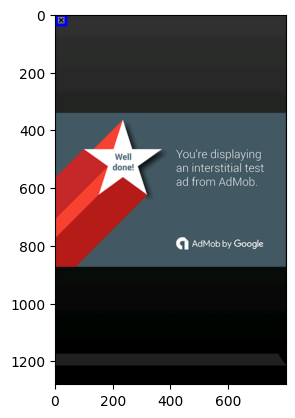

Generated caption: interstitial close button<e>
original caption: <s>navigate up<e>


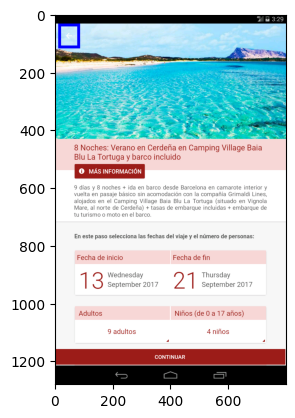

Generated caption: open navigation drawer<e>
original caption: <s>navigate up<e>


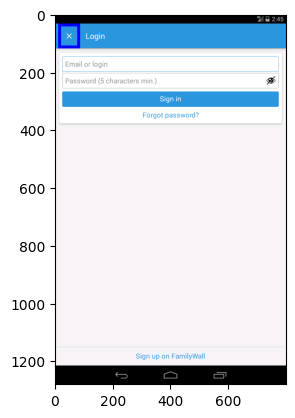

Generated caption: open navigation drawer<e>
original caption: <s>more option<e>


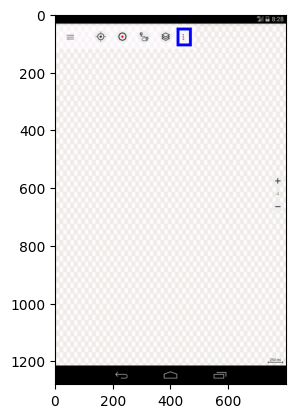

Generated caption: more option<e>
original caption: <s>menu closed<e>


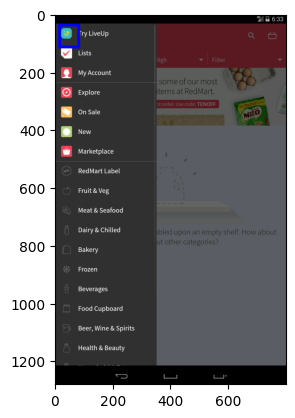

Generated caption: navigate up<e>


In [16]:
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

temp = test_df[:100]

for i in range(3):
  
  img_path=temp.image.iloc[i]
  img=Image.open(img_path).convert("RGB")

  roi=temp.bounds.iloc[i]
  img2=img.crop(roi)
  
  print(f"original caption: {temp.caption.iloc[i]}")
  p1=feature_extractor(img, return_tensors="pt").pixel_values
  p2=feature_extractor(img2, return_tensors="pt").pixel_values
  pixel_values=torch.cat([p1,p2],dim=1)
  
  draw = ImageDraw.Draw(img)
  draw.rectangle(roi, outline="blue",width=10)
  plt.imshow(img)
  plt.show()
  output = model.generate(pixel_values.to(device))
    # decode the output
  caption = tokenizer.batch_decode(output, skip_special_tokens=True)[0]
  print(f"Generated caption: {caption}")
